In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

train.info()

print("\nMissing values:\n")
print(train.isnull().sum())
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis (EDA)

In this step, we explore the dataset to understand its structure, data types, and identify missing values. This helps us determine how to clean and prepare the data for modeling.

In [6]:
train.info()

print("\nMissing values:\n")
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         

## Data Cleaning Strategy

From the exploratory analysis, we identified missing values in several columns:

- Age has 177 missing values, which will be filled using the median.
- Cabin has 687 missing values, so it will be dropped due to excessive missing data.
- Embarked has only 2 missing values, which will be filled using the most frequent value.

These steps ensure the dataset is clean and ready for modeling.

In [7]:
# Fill Age with median
train['Age'] = train['Age'].fillna(train['Age'].median())

# Fill Embarked with mode
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Drop Cabin
train = train.drop('Cabin', axis=1)
train.isnull().sum
train = train.drop('Cabin', axis=1, errors='ignore')

## Data Visualization

In this section, we explore relationships between different features and survival. This helps us understand which factors influenced survival rates.

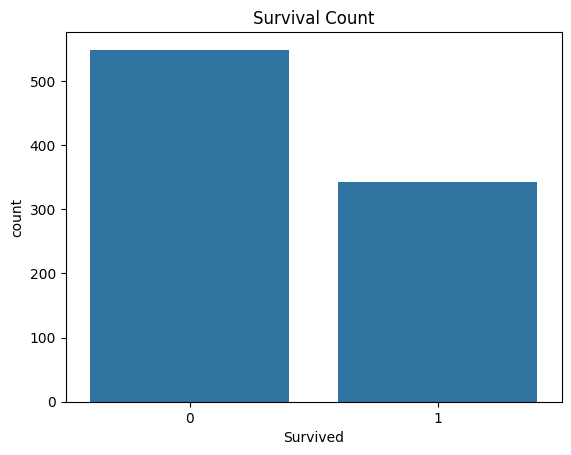

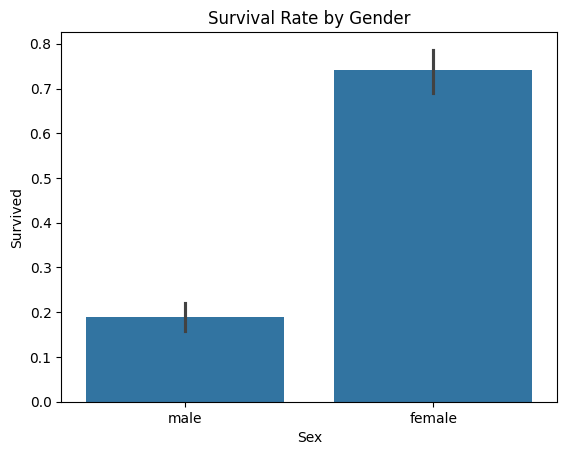

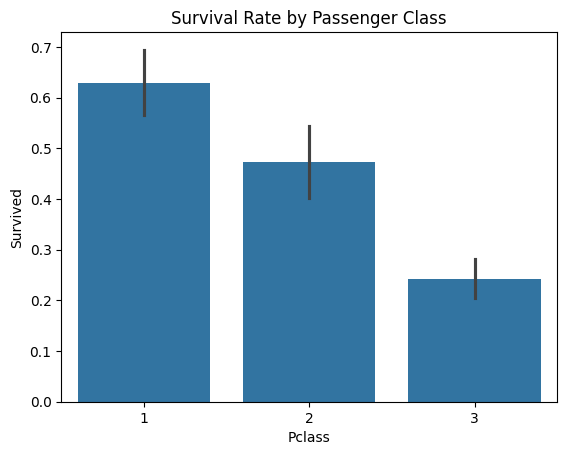

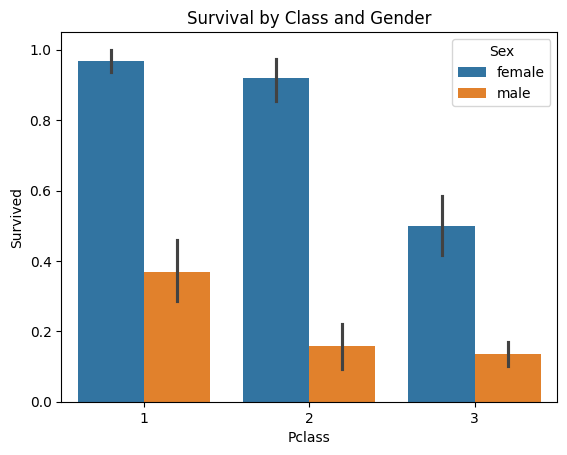

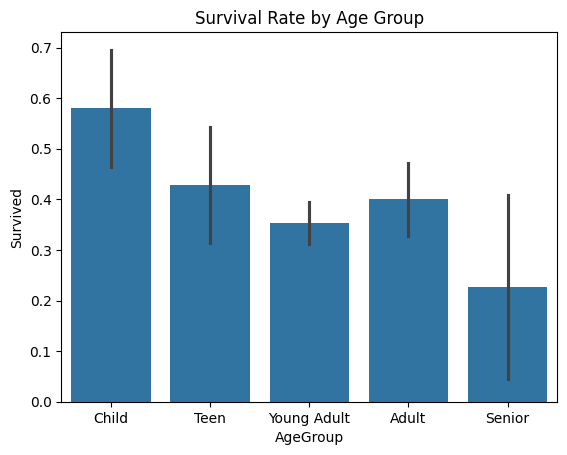

In [8]:
# Survival count
sns.countplot(x='Survived', data=train)
plt.title("Survival Count")
plt.show()

# Survival by gender
sns.barplot(x='Sex', y='Survived', data=train)
plt.title("Survival Rate by Gender")
plt.show()

# Survival by class
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title("Survival Rate by Passenger Class")
plt.show()

# Survival by class and gender
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train)
plt.title('Survival by Class and Gender')
plt.show()

# Create age groups
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 18, 35, 60, 80],
                           labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

#survival rate by age group
sns.barplot(x='AgeGroup', y='Survived', data=train)
plt.title('Survival Rate by Age Group')
plt.show()

## Feature Engineering

In this step, we convert categorical variables into numerical format so that they can be used in machine learning models.

In [9]:
# Convert Sex to numbers
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked to dummy variables
train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,AgeGroup,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,Young Adult,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,Adult,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,Young Adult,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,Young Adult,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,Young Adult,False,True


## Feature Selection

In this step, we select the most relevant features from the dataset that will be used to train the machine learning model. These features are chosen based on their potential influence on survival.

In [10]:
X = train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
y = train['Survived']
print(X.head())
print(y.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3    0  22.0      1      0   7.2500       False        True
1       1    1  38.0      1      0  71.2833       False       False
2       3    1  26.0      0      0   7.9250       False        True
3       1    1  35.0      1      0  53.1000       False        True
4       3    0  35.0      0      0   8.0500       False        True
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


## Train-Test Split

The dataset is split into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X_train.shape)
print(X_test.shape)

(712, 8)
(179, 8)


## Model Training

In this step, we train a Logistic Regression model using the training data. This model will learn patterns in the data to predict survival.

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

After training the model, we evaluate its performance using the test data. Accuracy is used as the evaluation metric to measure how well the model predicts survival.

In [13]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.7988826815642458


## Random Forest Model

In this section, we use a Random Forest Classifier, which is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.8268156424581006


## Model Comparison

Two machine learning models were used in this project:

- Logistic Regression achieved approximately 80% accuracy.
- Random Forest Classifier achieved approximately 81% accuracy.

The Random Forest model performed slightly better because it can capture more complex relationships between features by combining multiple decision trees.

## Feature Importance Analysis
In this step, we analyze which features had the greatest influence on passenger survival predictions in the Random Forest model.

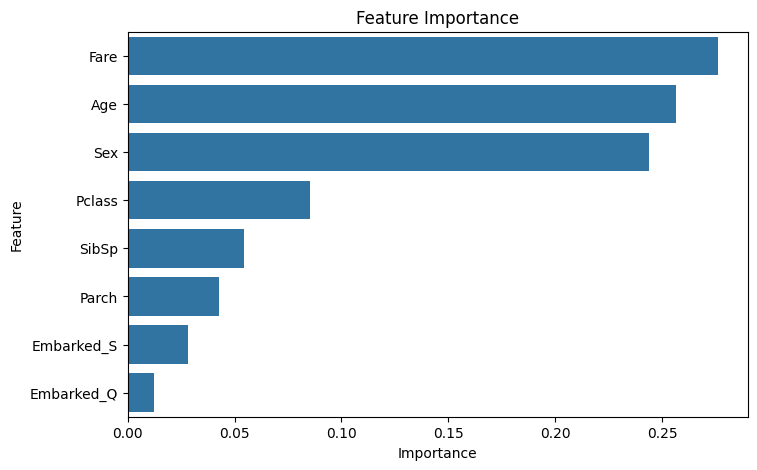

,Feature,Importance
5,Fare,0.276152
2,Age,0.256636
1,Sex,0.244050
0,Pclass,0.085136
3,SibSp,0.054542
4,Parch,0.042931
7,Embarked_S,0.028074
6,Embarked_Q,0.012479


In [15]:
# Get feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title('Feature Importance')
plt.show()

# Show table
feature_importance

## Feature Importance Findings

The Random Forest model identified Fare as one of the most influential features in predicting survival. This suggests that passengers who paid higher ticket fares had a greater likelihood of survival, likely due to better passenger class accommodations and access to safety resources.

## Confusion Matrix

A confusion matrix is used to evaluate classification models by comparing predicted values with actual values. It helps identify correct and incorrect predictions made by the model.

In [16]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

print(cm)

[[91 18]
 [13 57]]


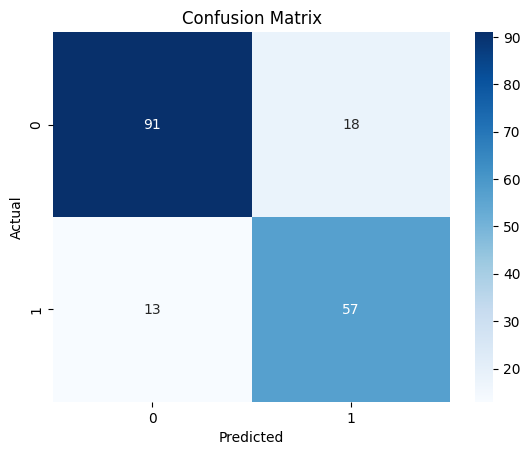

In [17]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

## Classification Report

The classification report provides additional evaluation metrics including precision, recall, and F1-score. These metrics help assess model performance beyond overall accuracy.

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85       109
           1       0.76      0.81      0.79        70

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

